PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64
Missing values after cleaning: 2074
Linear Regression:
Mean Squared Error: 2303661644.5281973
R2 Score: 0.6996657531501519
Random Forest:
Mean Squared Error: 1497337113.0745435
R2 Score: 0.8047883398138227


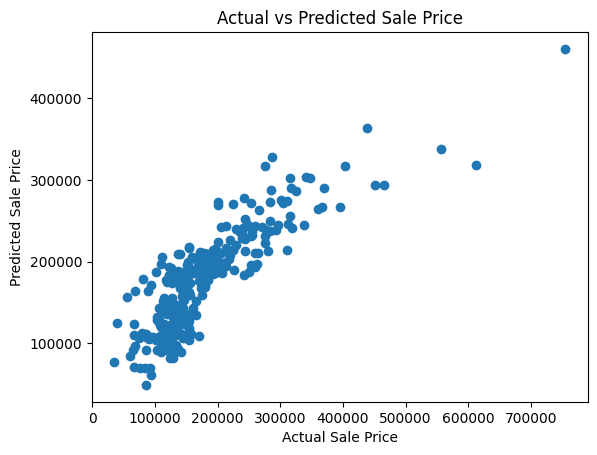

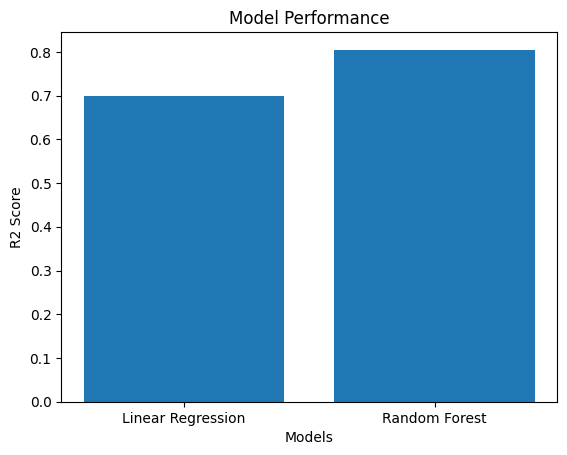

Predicted Sale Price: 198139.39707143404


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
df=pd.read_csv("train.csv")
df.shape
df.head()
missing=df.isnull().sum()
missing=missing[missing >0]
print(missing.sort_values(ascending=False).head(10))
df.drop(['Alley','PoolQC','Fence','MiscFeature'],axis=1,inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)
print("Missing values after cleaning:",df.isnull().sum().sum())
df.head(10)
feature=['GrLivArea','BedroomAbvGr','FullBath','GarageCars']
target=['SalePrice']
X=df[feature]
y=df[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
lr=LinearRegression()
lr.fit(X_train,y_train.values.ravel()) # Fix for DataConversionWarning
y_pred=lr.predict(X_test)
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train.values.ravel()) # Fix for DataConversionWarning
y_pred_rf=rf.predict(X_test)
print("Linear Regression:")
print("Mean Squared Error:",mean_squared_error(y_test,y_pred))
print("R2 Score:",r2_score(y_test,y_pred))
print("Random Forest:")
print("Mean Squared Error:",mean_squared_error(y_test,y_pred_rf))
print("R2 Score:",r2_score(y_test,y_pred_rf))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price")
plt.show()
models=['Linear Regression','Random Forest']
scores=[r2_score(y_test,y_pred),r2_score(y_test,y_pred_rf)]
plt.bar(models,scores)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Performance")
plt.show()
area=2000
bedrooms=3
bath=2
garage=1
# age=10 # 'age' was not used as a feature during training, so it should be removed from input_data
input_data=np.array([[area,bedrooms,bath,garage]]) # Corrected to match the 4 features used for training
predicted_price=lr.predict(input_data)
print("Predicted Sale Price:",predicted_price[0])